# ERP analysis using find_eog_events() For Eye blink and Peak to peak amplitude for the Epoch selection   ; For subject SD031; SD030, SD025, SD020 and SD015

In [1]:
# read the data
import matplotlib.pyplot as plt
import numpy as np
#import pandas as pd
import matplotlib

import mne
import os
from mne.preprocessing import ICA

In [2]:
## Some of the common function 
def identify_bad_channels(data, threshold=80e-6):
    """
    Identify bad channels based on amplitude difference exceeding the threshold.
    
    :param data: 3D array of shape (n_epochs, n_channels, n_times)
    :param threshold: Amplitude difference threshold in Volts (default: 80 microvolts)
    :return: List of bad channel indices
    """
    amplitude_diff = np.ptp(data, axis=2)  # peak-to-peak amplitude for each epoch and channel
    bad_channels = np.where(np.any(amplitude_diff > threshold, axis=0))[0]
    return bad_channels.tolist()


def remove_epochs_with_bad_mmn_channels(epochs, mmn_channels, amplitude_threshold=80e-6):
    """
    Remove epochs where MMN-related channels exceed the amplitude threshold.
    
    :param epochs: mne.Epochs object
    :param mmn_channels: List of MMN channel names
    :param amplitude_threshold: Amplitude difference threshold in Volts (default: 80 microvolts)
    :return: mne.Epochs object with bad epochs removed
    """
    data = epochs.get_data()
    
    
    bad_mmn_epochs = []
    for epoch_idx in range(len(epochs)):
        epoch_data = data[epoch_idx]
        epoch_bad_channels = identify_bad_channels(epoch_data[np.newaxis, :, :], amplitude_threshold)
        
        for ch_idx in epoch_bad_channels:
            ch_name = epochs.ch_names[ch_idx]
            if any(mmn_ch in ch_name for mmn_ch in mmn_channels):
                bad_mmn_epochs.append(epoch_idx)
                break
    
    good_epochs = np.setdiff1d(np.arange(len(epochs)), bad_mmn_epochs)
    return epochs[good_epochs]



In [3]:

data_folder = r"D:\Work_data\Notification_evoked_response\Data_at_IITD/"
subjects = os.listdir(data_folder)
data_type = "EEG"
 # it is useful to scroll eeg data 
%matplotlib qt

### Subject SD031 analysis

In [4]:
subject = "SD031"
path = os.path.join(data_folder,subject,data_type)
for eeg in os.listdir(path):
    if eeg[-5:] == ".vhdr":
            break

the default scaling of 20e-6 (20µV) for EEG signals means that the visualized range will be 40 µV (20 µV in the positive direction and 20 µV in the negative direction).

Extracting parameters from D:\Work_data\Notification_evoked_response\Data_at_IITD/SD031\EEG\SD031.vhdr...
Setting channel info structure...
Reading 0 ... 2373159  =      0.000 ...  2373.159 secs...
Using matplotlib as 2D backend.


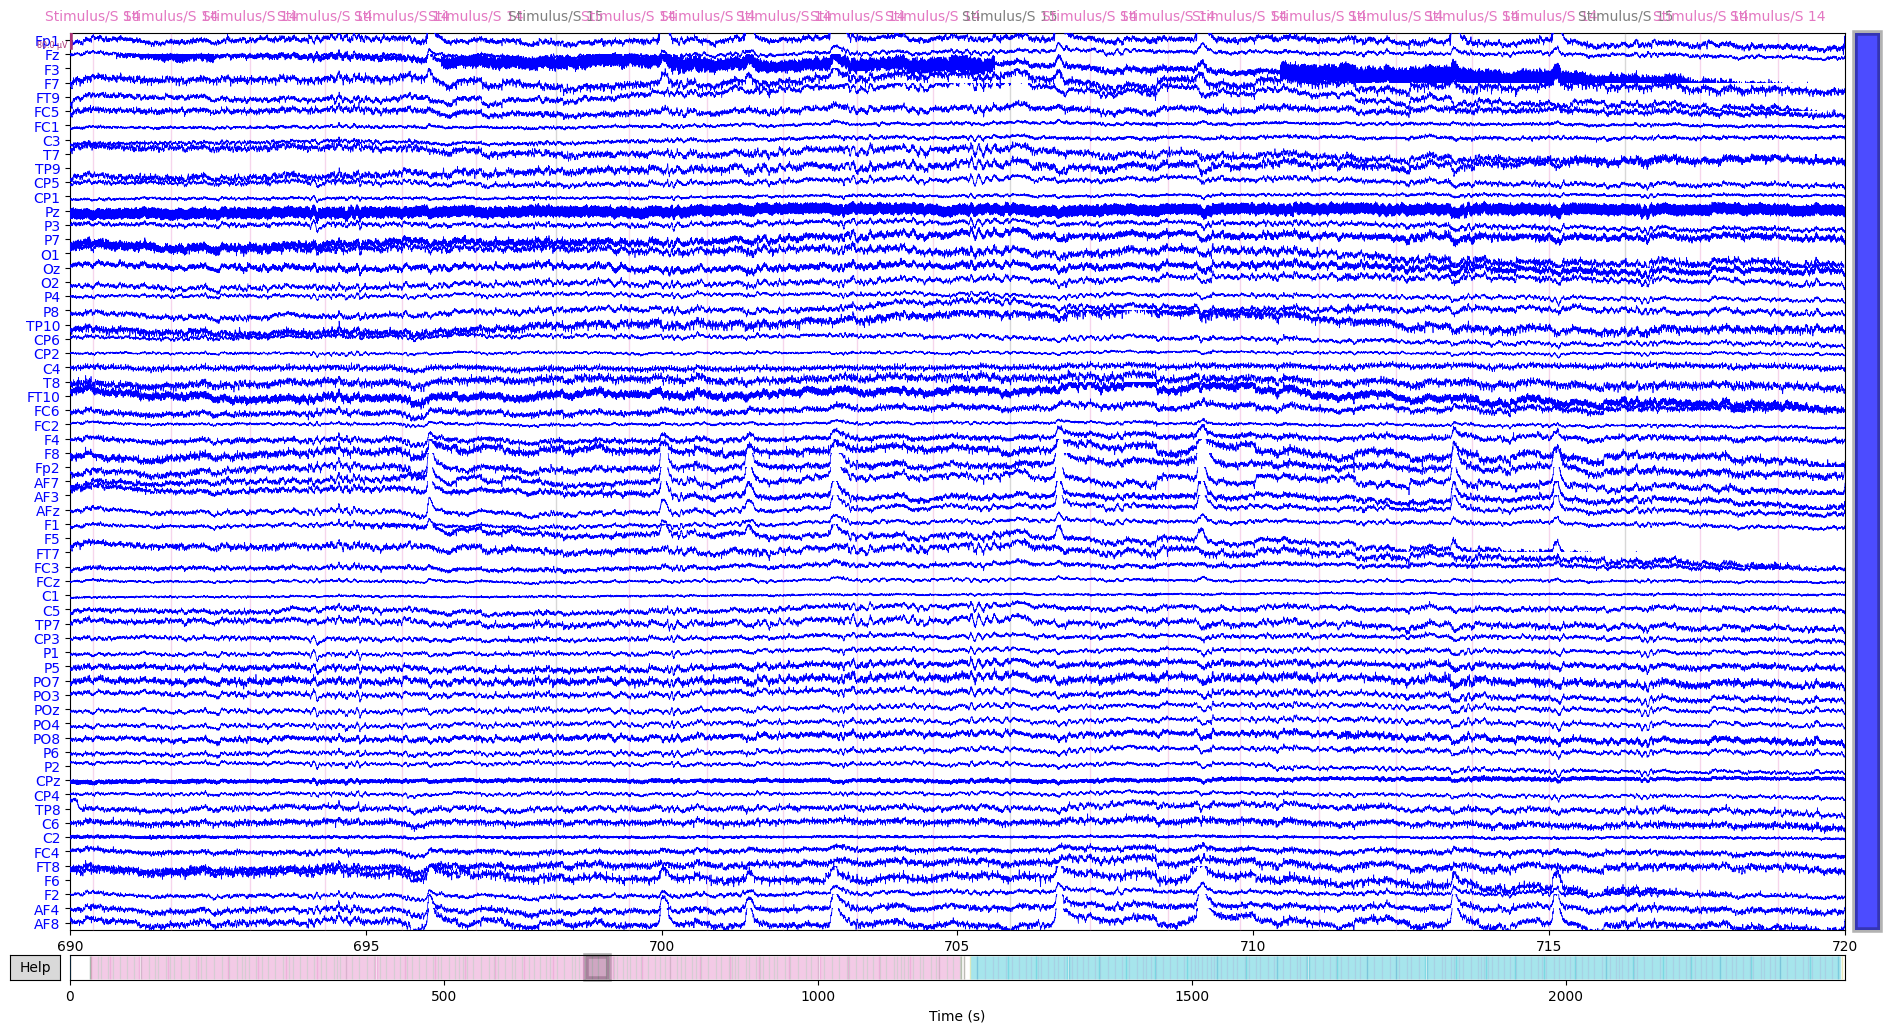

In [5]:
raw = mne.io.read_raw_brainvision(os.path.join(path,eeg), preload=True)
raw.set_montage("easycap-M1")
raw.plot(scalings=dict(eeg=40e-6),clipping='transparent',duration=30.0, start=690.0, n_channels=63,color = "Blue",event_color ='black',show_options=True )

Approximating Fpz location by mirroring Oz along the X and Y axes.


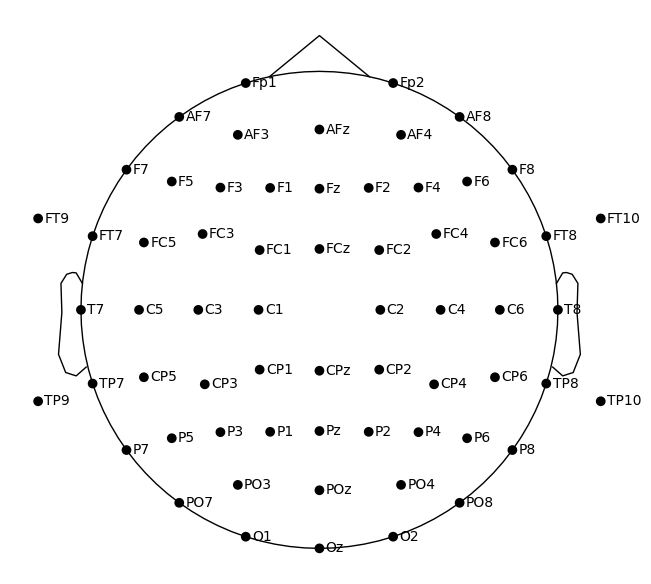

In [6]:
raw.plot_sensors(show_names=True, sphere="eeglab")

In [7]:
# Crop the Block1 ; if required 

"""events,event_dict = mne.events_from_annotations(raw)

# Define the event ID for segmentation
segment_event_id = 11  # Replace with your actual event ID

# Find indices of segment events
segment_indices = np.where(events[:, 2] == segment_event_id)[0]

# Crop the data between each pair of segment events
cropped_data = []
for i in range(len(segment_indices) - 1):
    start_time = events[segment_indices[i], 0] / raw.info['sfreq']
    end_time = events[segment_indices[i+1], 0] / raw.info['sfreq']
    segment = raw.copy().crop(tmin=start_time, tmax=end_time)
    cropped_data.append(segment)

# Concatenate all cropped segments
if cropped_data:
    B1_raw = mne.concatenate_raws(cropped_data)
    print(f"Data cropped to {len(cropped_data)} segments")
else:
    print("No segments found")
    B1_raw = raw
B1_raw.plot(scalings=dict(eeg=40e-6),clipping='transparent',duration=30.0, start=690.0, n_channels=63,color = "Blue" )"""

'events,event_dict = mne.events_from_annotations(raw)\n\n# Define the event ID for segmentation\nsegment_event_id = 11  # Replace with your actual event ID\n\n# Find indices of segment events\nsegment_indices = np.where(events[:, 2] == segment_event_id)[0]\n\n# Crop the data between each pair of segment events\ncropped_data = []\nfor i in range(len(segment_indices) - 1):\n    start_time = events[segment_indices[i], 0] / raw.info[\'sfreq\']\n    end_time = events[segment_indices[i+1], 0] / raw.info[\'sfreq\']\n    segment = raw.copy().crop(tmin=start_time, tmax=end_time)\n    cropped_data.append(segment)\n\n# Concatenate all cropped segments\nif cropped_data:\n    B1_raw = mne.concatenate_raws(cropped_data)\n    print(f"Data cropped to {len(cropped_data)} segments")\nelse:\n    print("No segments found")\n    B1_raw = raw\nB1_raw.plot(scalings=dict(eeg=40e-6),clipping=\'transparent\',duration=30.0, start=690.0, n_channels=63,color = "Blue" )'

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 33001 samples (33.001 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    1.8s


Used Annotations descriptions: ['Comment/Active Shielding: On', 'New Segment/', 'Stimulus/S 11', 'Stimulus/S 12', 'Stimulus/S 13', 'Stimulus/S 14', 'Stimulus/S 15', 'Stimulus/S 21', 'Stimulus/S 24', 'Stimulus/S 25']
Using EOG channels: Fp1, Fp2, F7, F8, AF7, AF8
EOG channel index for this subject is: [ 0 30  3 29 31 62]
Filtering the data to remove DC offset to help distinguish blinks from saccades
Selecting channel Fp1 for blink detection
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 10000 samples (10.000 s)

Now detecting blinks and generating corresponding events
Found 444 sig

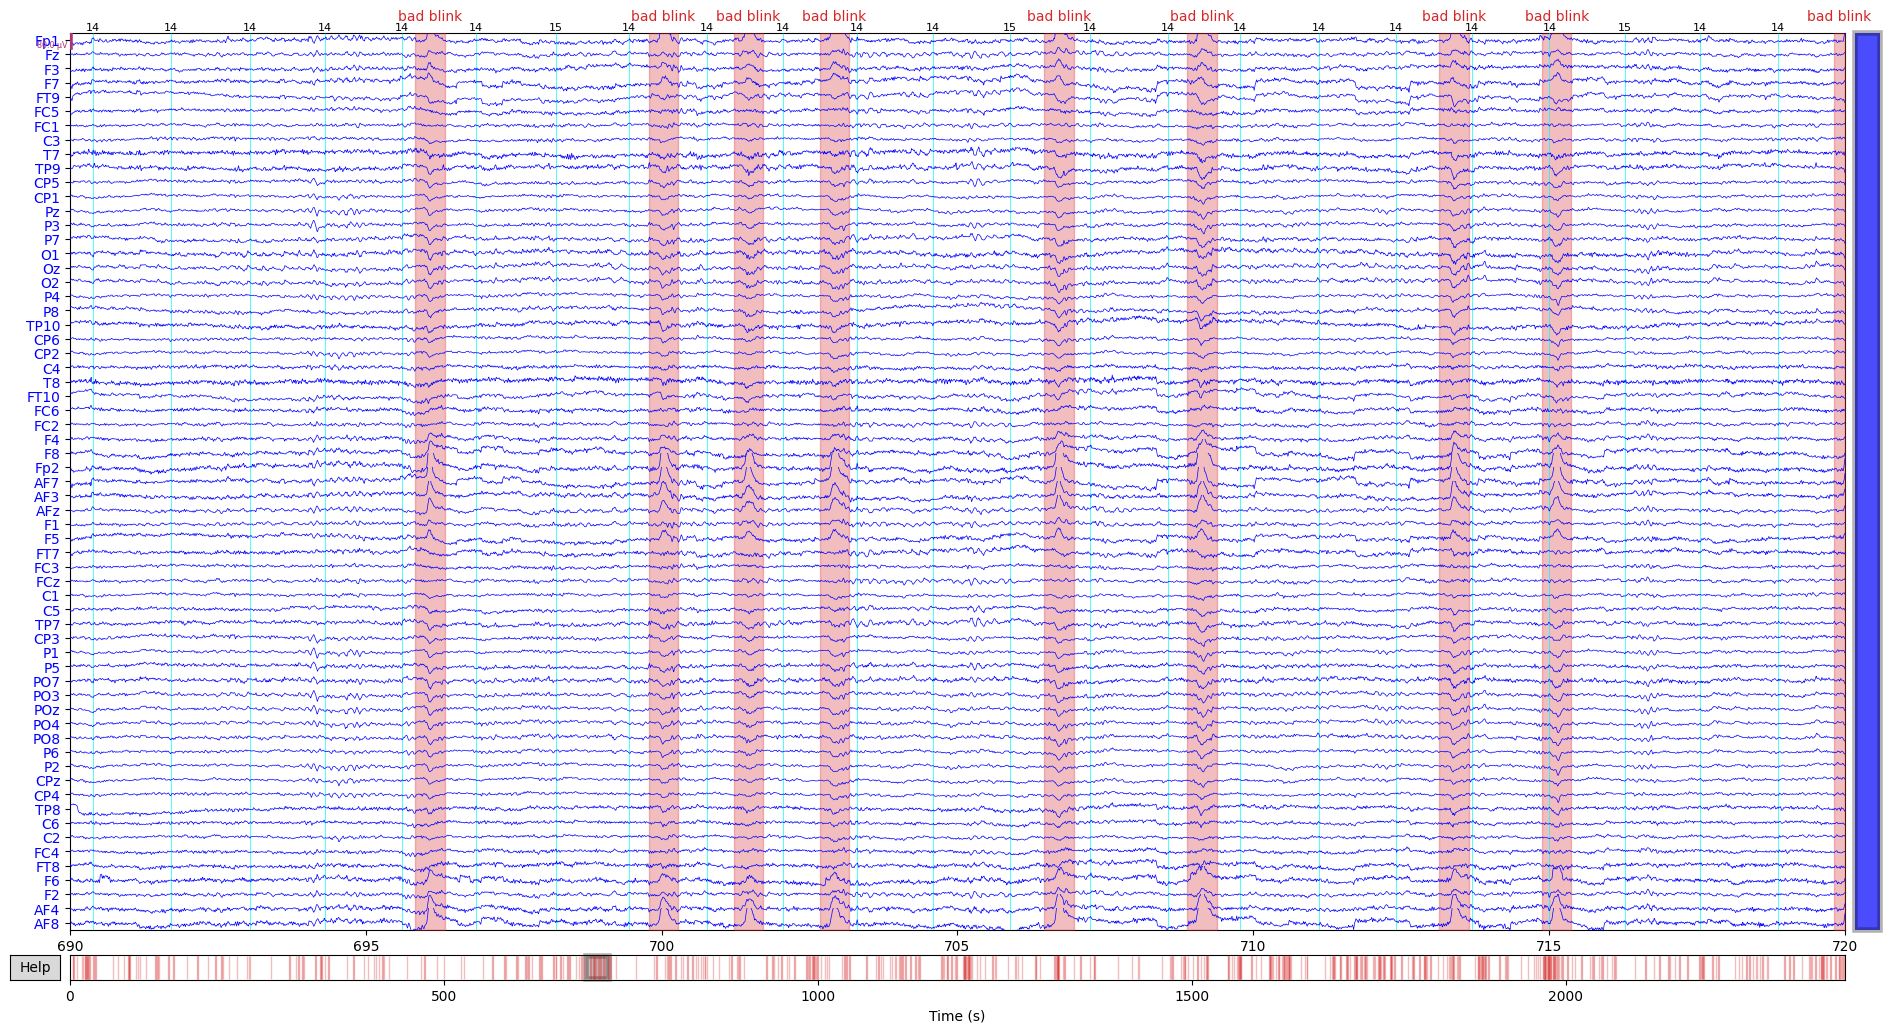

In [8]:
# Now re-reference the data :-n average reference 
raw.set_eeg_reference('average')
# filter 
raw.filter(l_freq=0.1,h_freq=40)

eog_channels = ['Fp1', 'Fp2', 'F7', 'F8',"AF7",'AF8']  # Adjust these to match your channel names
 
events,event_dict = mne.events_from_annotations(raw)



eog_events = mne.preprocessing.find_eog_events(raw,ch_name=eog_channels)
onsets = eog_events[:, 0] / raw.info["sfreq"] - 0.25
durations = [0.5] * len(eog_events)
descriptions = ["bad blink"] * len(eog_events)
blink_annot = mne.Annotations(
    onsets, durations, descriptions, orig_time=raw.info["meas_date"]
)
raw.set_annotations(blink_annot)

raw.plot(events =events , scalings=dict(eeg=40e-6),clipping='transparent',duration=30.0, start=690.0, n_channels=63,color = "Blue" )

In [9]:

# Create Epochs
epochs = mne.Epochs(raw, events, event_id=[14,15] ,tmin=-0.300, tmax=0.700,
                    baseline=(None, 0), reject_by_annotation=True,
                    preload=True)


# Define your MMN channels
mmn_channels = ['F3', 'Fz', 'F4',]  # Example MMN channels, adjust as needed

# Remove epochs with bad MMN channels
cleaned_epochs = remove_epochs_with_bad_mmn_channels(epochs, mmn_channels)

print(f"Original number of epochs: {len(epochs)}")
print(f"Number of epochs after removal: {len(cleaned_epochs)}")
B1_devi_eps = cleaned_epochs['15'].average()
B1_sta_eps = cleaned_epochs["14"].average()
B1_MMN_erp = mne.combine_evoked([ B1_devi_eps,B1_sta_eps], weights=[1,-1])


evokeds = dict(B1_MMN_erp =B1_MMN_erp, B1_devi_eps= B1_devi_eps,B1_sta_eps=B1_sta_eps)  
#picks = [n for n in range(1, 5)]
picks= [ 'Fz']
mne.viz.plot_compare_evokeds(evokeds, picks=picks,title  = "SD031 on avaerage 'F3', 'Fz', 'F4'", combine="mean")

Not setting metadata
900 matching events found
Setting baseline interval to [-0.3, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 900 events and 1001 original time points ...
192 bad epochs dropped


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_27952\88319035.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


Original number of epochs: 708
Number of epochs after removal: 510
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_27952\2580028089.py:23: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds, picks=picks,title  = "SD031 on avaerage 'F3', 'Fz', 'F4'", combine="mean")


[<Figure size 800x600 with 2 Axes>]

In [10]:
"""The script will now produce  plots:

1 ) A heatmap of t-values across time and channels
2 ) The MMN plot with significant time points highlighted.
"""
from scipy import stats
# Calculate the mean across trials for each condition
data_standard = cleaned_epochs['14'].get_data()
data_deviant = cleaned_epochs['15'].get_data()
mean_standard = np.mean(data_standard, axis=0)
mean_deviant = np.mean(data_deviant, axis=0)

# Perform t-test at each time point and channel
t_values, p_values = stats.ttest_ind(data_standard, data_deviant, axis=0)

# Plot t-values
plt.figure(figsize=(10, 6))
plt.imshow(t_values, aspect='auto', extent=[cleaned_epochs.times[0], cleaned_epochs.times[-1], 0, t_values.shape[0]], 
           cmap='RdBu_r', vmin=-5, vmax=5)
plt.colorbar(label='t-value')
plt.xlabel('Time (s)')
plt.ylabel('Channels')
plt.title('SD031 T-values: Deviant vs Standard')
plt.show()

# Plot significant time points
sig_times = cleaned_epochs.times[np.any(p_values < 0.05, axis=0)]
plt.figure(figsize=(10, 6))
for time in sig_times:
    plt.axvline(x=time, color='r', linestyle='--', alpha=0.5)
plt.plot(cleaned_epochs.times, B1_MMN_erp.data.T)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('SD031 MMN with Significant Time Points')
plt.show()


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_27952\113459637.py:8: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data_standard = cleaned_epochs['14'].get_data()
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_27952\113459637.py:9: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data_deviant = cleaned_epochs['15'].get_data()


### Sub030

Extracting parameters from D:\Work_data\Notification_evoked_response\Data_at_IITD/SD030\EEG\SD030.vhdr...
Setting channel info structure...
Reading 0 ... 2433639  =      0.000 ...  2433.639 secs...


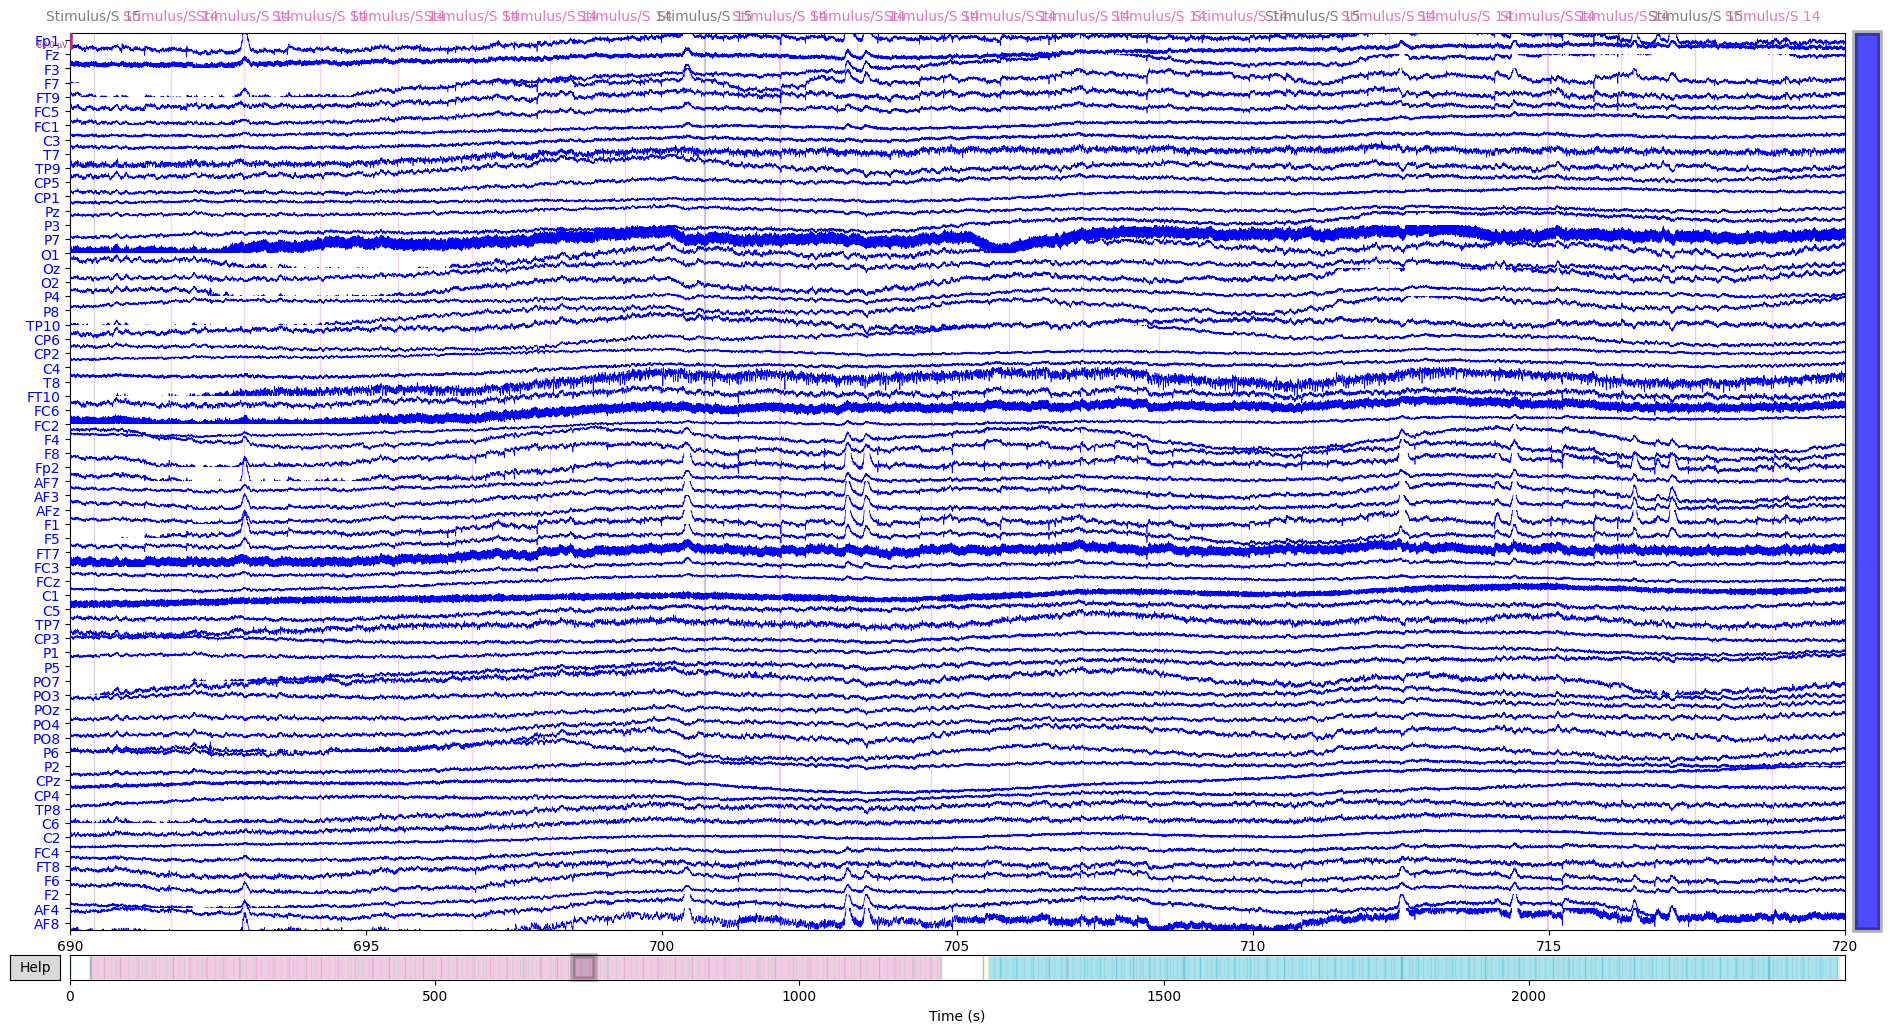

In [11]:
subject = "SD030"
path = os.path.join(data_folder,subject,data_type)
for eeg in os.listdir(path):
    if eeg[-5:] == ".vhdr":
            break
raw = mne.io.read_raw_brainvision(os.path.join(path,eeg), preload=True)
raw.set_montage("easycap-M1")
raw.plot(scalings=dict(eeg=40e-6),clipping='transparent',duration=30.0, start=690.0, n_channels=63,color = "Blue",event_color ='black',show_options=True )

In [12]:
# Now re-reference the data :-n average reference 
raw.set_eeg_reference('average')
# filter 
raw.filter(l_freq=0.1,h_freq=40)

eog_channels = ['Fp1', 'Fp2', 'F7', 'F8',"AF7",'AF8']  # Adjust these to match your channel names
 
events,event_dict = mne.events_from_annotations(raw)



eog_events = mne.preprocessing.find_eog_events(raw,ch_name=eog_channels)
onsets = eog_events[:, 0] / raw.info["sfreq"] - 0.25
durations = [0.5] * len(eog_events)
descriptions = ["bad blink"] * len(eog_events)
blink_annot = mne.Annotations(
    onsets, durations, descriptions, orig_time=raw.info["meas_date"]
)
raw.set_annotations(blink_annot)

raw.plot(events =events , scalings=dict(eeg=40e-6),clipping='transparent',duration=30.0, start=690.0, n_channels=63,color = "Blue" )
# Create Epochs
epochs = mne.Epochs(raw, events, event_id=[14,15] ,tmin=-0.300, tmax=0.700,
                    baseline=(None, 0), reject_by_annotation=True,
                    preload=True)
# Create Epochs
epochs = mne.Epochs(raw, events, event_id=[14,15] ,tmin=-0.300, tmax=0.700,
                    baseline=(None, 0), reject_by_annotation=True,
                    preload=True)

# Define your MMN channels
mmn_channels = ['F3', 'Fz', 'F4',]  # Example MMN channels, adjust as needed

# Remove epochs with bad MMN channels
cleaned_epochs = remove_epochs_with_bad_mmn_channels(epochs, mmn_channels)

print(f"Original number of epochs: {len(epochs)}")
print(f"Number of epochs after removal: {len(cleaned_epochs)}")
B1_devi_eps = cleaned_epochs['15'].average()
B1_sta_eps = cleaned_epochs["14"].average()
B1_MMN_erp = mne.combine_evoked([ B1_devi_eps,B1_sta_eps], weights=[1,-1])


evokeds = dict(B1_MMN_erp =B1_MMN_erp, B1_devi_eps= B1_devi_eps,B1_sta_eps=B1_sta_eps)  
#picks = [n for n in range(1, 5)]
picks= [ 'Fz']
mne.viz.plot_compare_evokeds(evokeds, picks=picks,title  = "SD030 on avaerage 'F3', 'Fz', 'F4'", combine="mean")

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 33001 samples (33.001 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    2.0s


Used Annotations descriptions: ['Comment/Active Shielding: On', 'New Segment/', 'Stimulus/S 11', 'Stimulus/S 12', 'Stimulus/S 13', 'Stimulus/S 14', 'Stimulus/S 15', 'Stimulus/S 21', 'Stimulus/S 24', 'Stimulus/S 25']
Using EOG channels: Fp1, Fp2, F7, F8, AF7, AF8
EOG channel index for this subject is: [ 0 30  3 29 31 62]
Filtering the data to remove DC offset to help distinguish blinks from saccades
Selecting channel Fp1 for blink detection
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 10000 samples (10.000 s)

Now detecting blinks and generating corresponding events
Found 600 sig

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_27952\3734683630.py:19: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(blink_annot)


Not setting metadata
900 matching events found
Setting baseline interval to [-0.3, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 900 events and 1001 original time points ...
238 bad epochs dropped
Not setting metadata
900 matching events found
Setting baseline interval to [-0.3, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 900 events and 1001 original time points ...
238 bad epochs dropped


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_27952\88319035.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


Original number of epochs: 662
Number of epochs after removal: 617
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_27952\3734683630.py:47: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds, picks=picks,title  = "SD030 on avaerage 'F3', 'Fz', 'F4'", combine="mean")


[<Figure size 800x600 with 2 Axes>]

### SD025

Extracting parameters from D:\Work_data\Notification_evoked_response\Data_at_IITD/SD025\EEG\SD025.vhdr...
Setting channel info structure...
Reading 0 ... 2372779  =      0.000 ...  2372.779 secs...


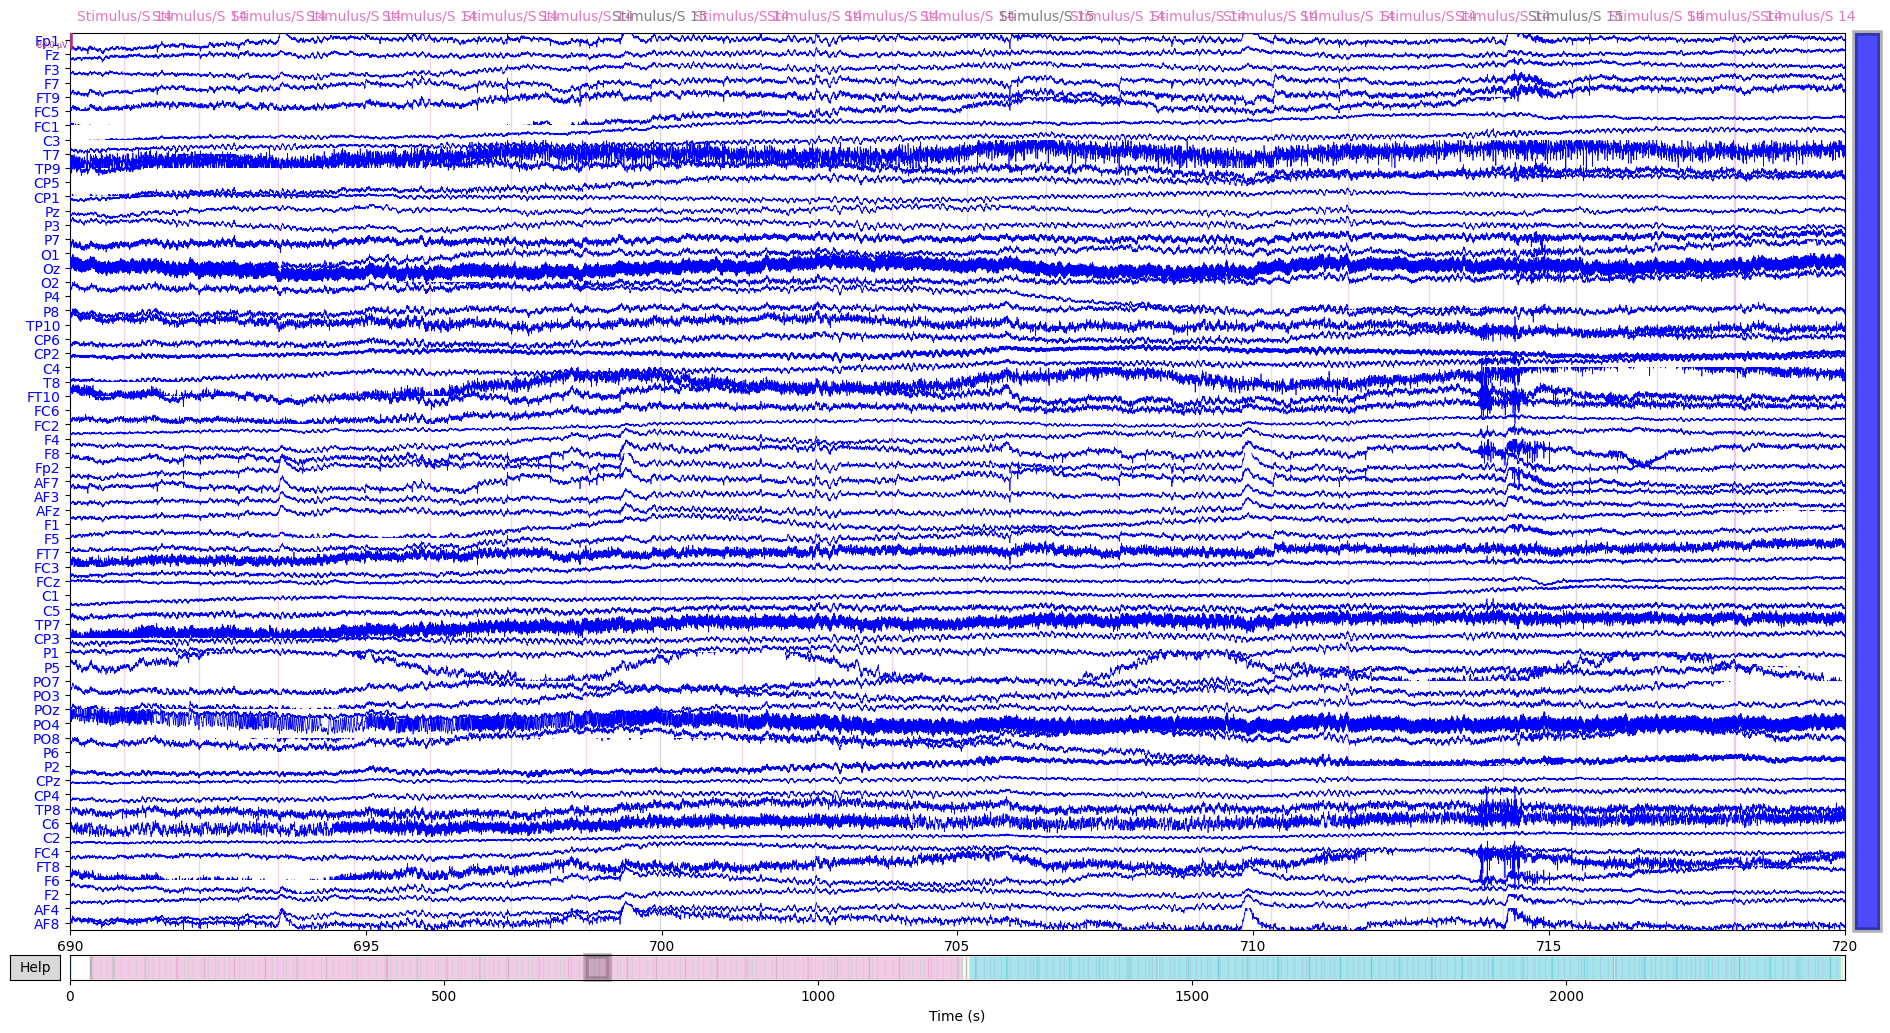

In [13]:
subject = "SD025"
path = os.path.join(data_folder,subject,data_type)
for eeg in os.listdir(path):
    if eeg[-5:] == ".vhdr":
            break
raw = mne.io.read_raw_brainvision(os.path.join(path,eeg), preload=True)
raw.set_montage("easycap-M1")
raw.plot(scalings=dict(eeg=40e-6),clipping='transparent',duration=30.0, start=690.0, n_channels=63,color = "Blue",event_color ='black',show_options=True )

In [14]:
# Now re-reference the data :-n average reference 
raw.set_eeg_reference('average')
# filter 
raw.filter(l_freq=0.1,h_freq=40)

eog_channels = ['Fp1', 'Fp2', 'F7', 'F8',"AF7",'AF8']  # Adjust these to match your channel names
 
events,event_dict = mne.events_from_annotations(raw)



eog_events = mne.preprocessing.find_eog_events(raw,ch_name=eog_channels)
onsets = eog_events[:, 0] / raw.info["sfreq"] - 0.25
durations = [0.5] * len(eog_events)
descriptions = ["bad blink"] * len(eog_events)
blink_annot = mne.Annotations(
    onsets, durations, descriptions, orig_time=raw.info["meas_date"]
)
raw.set_annotations(blink_annot)

raw.plot(events =events , scalings=dict(eeg=40e-6),clipping='transparent',duration=30.0, start=690.0, n_channels=63,color = "Blue" )
# Create Epochs
epochs = mne.Epochs(raw, events, event_id=[14,15] ,tmin=-0.300, tmax=0.700,
                    baseline=(None, 0), reject_by_annotation=True,
                    preload=True)
# Create Epochs
epochs = mne.Epochs(raw, events, event_id=[14,15] ,tmin=-0.300, tmax=0.700,
                    baseline=(None, 0), reject_by_annotation=True,
                    preload=True)

# Define your MMN channels
mmn_channels = ['F3', 'Fz', 'F4',]  # Example MMN channels, adjust as needed

# Remove epochs with bad MMN channels
cleaned_epochs = remove_epochs_with_bad_mmn_channels(epochs, mmn_channels)

print(f"Original number of epochs: {len(epochs)}")
print(f"Number of epochs after removal: {len(cleaned_epochs)}")
B1_devi_eps = cleaned_epochs['15'].average()
B1_sta_eps = cleaned_epochs["14"].average()
B1_MMN_erp = mne.combine_evoked([ B1_devi_eps,B1_sta_eps], weights=[1,-1])


evokeds = dict(B1_MMN_erp =B1_MMN_erp, B1_devi_eps= B1_devi_eps,B1_sta_eps=B1_sta_eps)  
#picks = [n for n in range(1, 5)]
picks= [ 'Fz']
mne.viz.plot_compare_evokeds(evokeds, picks=picks,title  = "SD025 on avaerage 'F3', 'Fz', 'F4'", combine="mean")

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 33001 samples (33.001 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    1.8s


Used Annotations descriptions: ['Comment/Active Shielding: On', 'New Segment/', 'Stimulus/S 11', 'Stimulus/S 12', 'Stimulus/S 13', 'Stimulus/S 14', 'Stimulus/S 15', 'Stimulus/S 21', 'Stimulus/S 24', 'Stimulus/S 25']
Using EOG channels: Fp1, Fp2, F7, F8, AF7, AF8
EOG channel index for this subject is: [ 0 30  3 29 31 62]
Filtering the data to remove DC offset to help distinguish blinks from saccades
Selecting channel AF8 for blink detection
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 10000 samples (10.000 s)

Now detecting blinks and generating corresponding events
Found 84 sign

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_27952\88319035.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


Original number of epochs: 869
Number of epochs after removal: 864
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_27952\3465440462.py:47: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds, picks=picks,title  = "SD025 on avaerage 'F3', 'Fz', 'F4'", combine="mean")


[<Figure size 800x600 with 2 Axes>]

### SD020

Extracting parameters from D:\Work_data\Notification_evoked_response\Data_at_IITD/SD020\EEG\SD020.vhdr...
Setting channel info structure...
Reading 0 ... 2535859  =      0.000 ...  2535.859 secs...


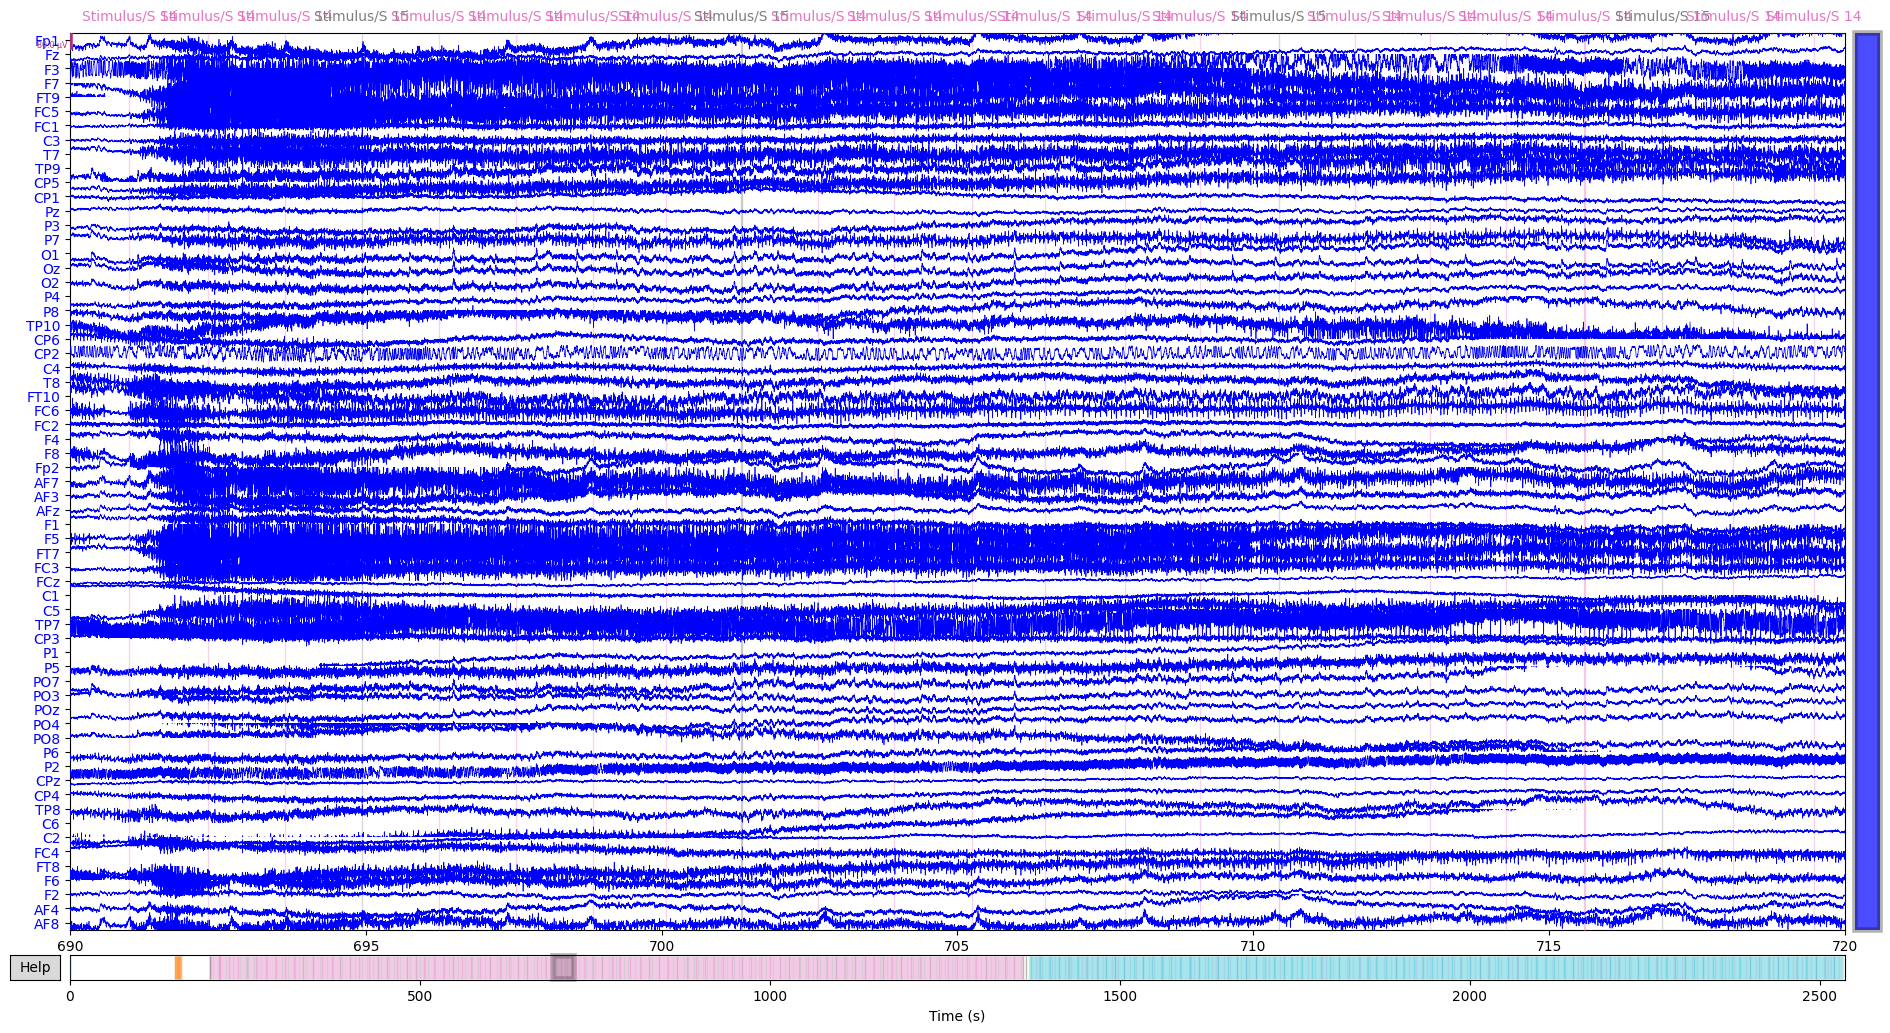

In [15]:
subject = "SD020"
path = os.path.join(data_folder,subject,data_type)
for eeg in os.listdir(path):
    if eeg[-5:] == ".vhdr":
            break
raw = mne.io.read_raw_brainvision(os.path.join(path,eeg), preload=True)
raw.set_montage("easycap-M1")
raw.plot(scalings=dict(eeg=40e-6),clipping='transparent',duration=30.0, start=690.0, n_channels=63,color = "Blue",event_color ='black',show_options=True )

In [16]:
# Now re-reference the data :-n average reference 
raw.set_eeg_reference('average')
# filter 
raw.filter(l_freq=0.1,h_freq=40)

eog_channels = ['Fp1', 'Fp2', 'F7', 'F8',"AF7",'AF8']  # Adjust these to match your channel names
 
events,event_dict = mne.events_from_annotations(raw)



eog_events = mne.preprocessing.find_eog_events(raw,ch_name=eog_channels)
onsets = eog_events[:, 0] / raw.info["sfreq"] - 0.25
durations = [0.5] * len(eog_events)
descriptions = ["bad blink"] * len(eog_events)
blink_annot = mne.Annotations(
    onsets, durations, descriptions, orig_time=raw.info["meas_date"]
)
raw.set_annotations(blink_annot)

raw.plot(events =events , scalings=dict(eeg=40e-6),clipping='transparent',duration=30.0, start=690.0, n_channels=63,color = "Blue" )
# Create Epochs
epochs = mne.Epochs(raw, events, event_id=[14,15] ,tmin=-0.300, tmax=0.700,
                    baseline=(None, 0), reject_by_annotation=True,
                    preload=True)
# Create Epochs
epochs = mne.Epochs(raw, events, event_id=[14,15] ,tmin=-0.300, tmax=0.700,
                    baseline=(None, 0), reject_by_annotation=True,
                    preload=True)

# Define your MMN channels
mmn_channels = ['F3', 'Fz', 'F4',]  # Example MMN channels, adjust as needed

# Remove epochs with bad MMN channels
cleaned_epochs = remove_epochs_with_bad_mmn_channels(epochs, mmn_channels)

print(f"Original number of epochs: {len(epochs)}")
print(f"Number of epochs after removal: {len(cleaned_epochs)}")
B1_devi_eps = cleaned_epochs['15'].average()
B1_sta_eps = cleaned_epochs["14"].average()
B1_MMN_erp = mne.combine_evoked([ B1_devi_eps,B1_sta_eps], weights=[1,-1])


evokeds = dict(B1_MMN_erp =B1_MMN_erp, B1_devi_eps= B1_devi_eps,B1_sta_eps=B1_sta_eps)  
#picks = [n for n in range(1, 5)]
picks= [ 'Fz']
mne.viz.plot_compare_evokeds(evokeds, picks=picks,title  = "SD020 on avaerage 'F3', 'Fz', 'F4'", combine="mean")

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 33001 samples (33.001 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    1.9s


Used Annotations descriptions: ['Comment/Active Shielding: On', 'New Segment/', 'Stimulus/S 11', 'Stimulus/S 12', 'Stimulus/S 13', 'Stimulus/S 14', 'Stimulus/S 15', 'Stimulus/S 21', 'Stimulus/S 24', 'Stimulus/S 25', 'Stimulus/S255']
Using EOG channels: Fp1, Fp2, F7, F8, AF7, AF8
EOG channel index for this subject is: [ 0 30  3 29 31 62]
Filtering the data to remove DC offset to help distinguish blinks from saccades
Selecting channel AF8 for blink detection
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 10000 samples (10.000 s)

Now detecting blinks and generating corresponding eve

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_27952\88319035.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


Original number of epochs: 900
Number of epochs after removal: 776
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_27952\2393123294.py:47: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds, picks=picks,title  = "SD020 on avaerage 'F3', 'Fz', 'F4'", combine="mean")


[<Figure size 800x600 with 2 Axes>]

### SD015

Extracting parameters from D:\Work_data\Notification_evoked_response\Data_at_IITD/SD015\EEG\SD015.vhdr...
Setting channel info structure...
Reading 0 ... 2371899  =      0.000 ...  2371.899 secs...


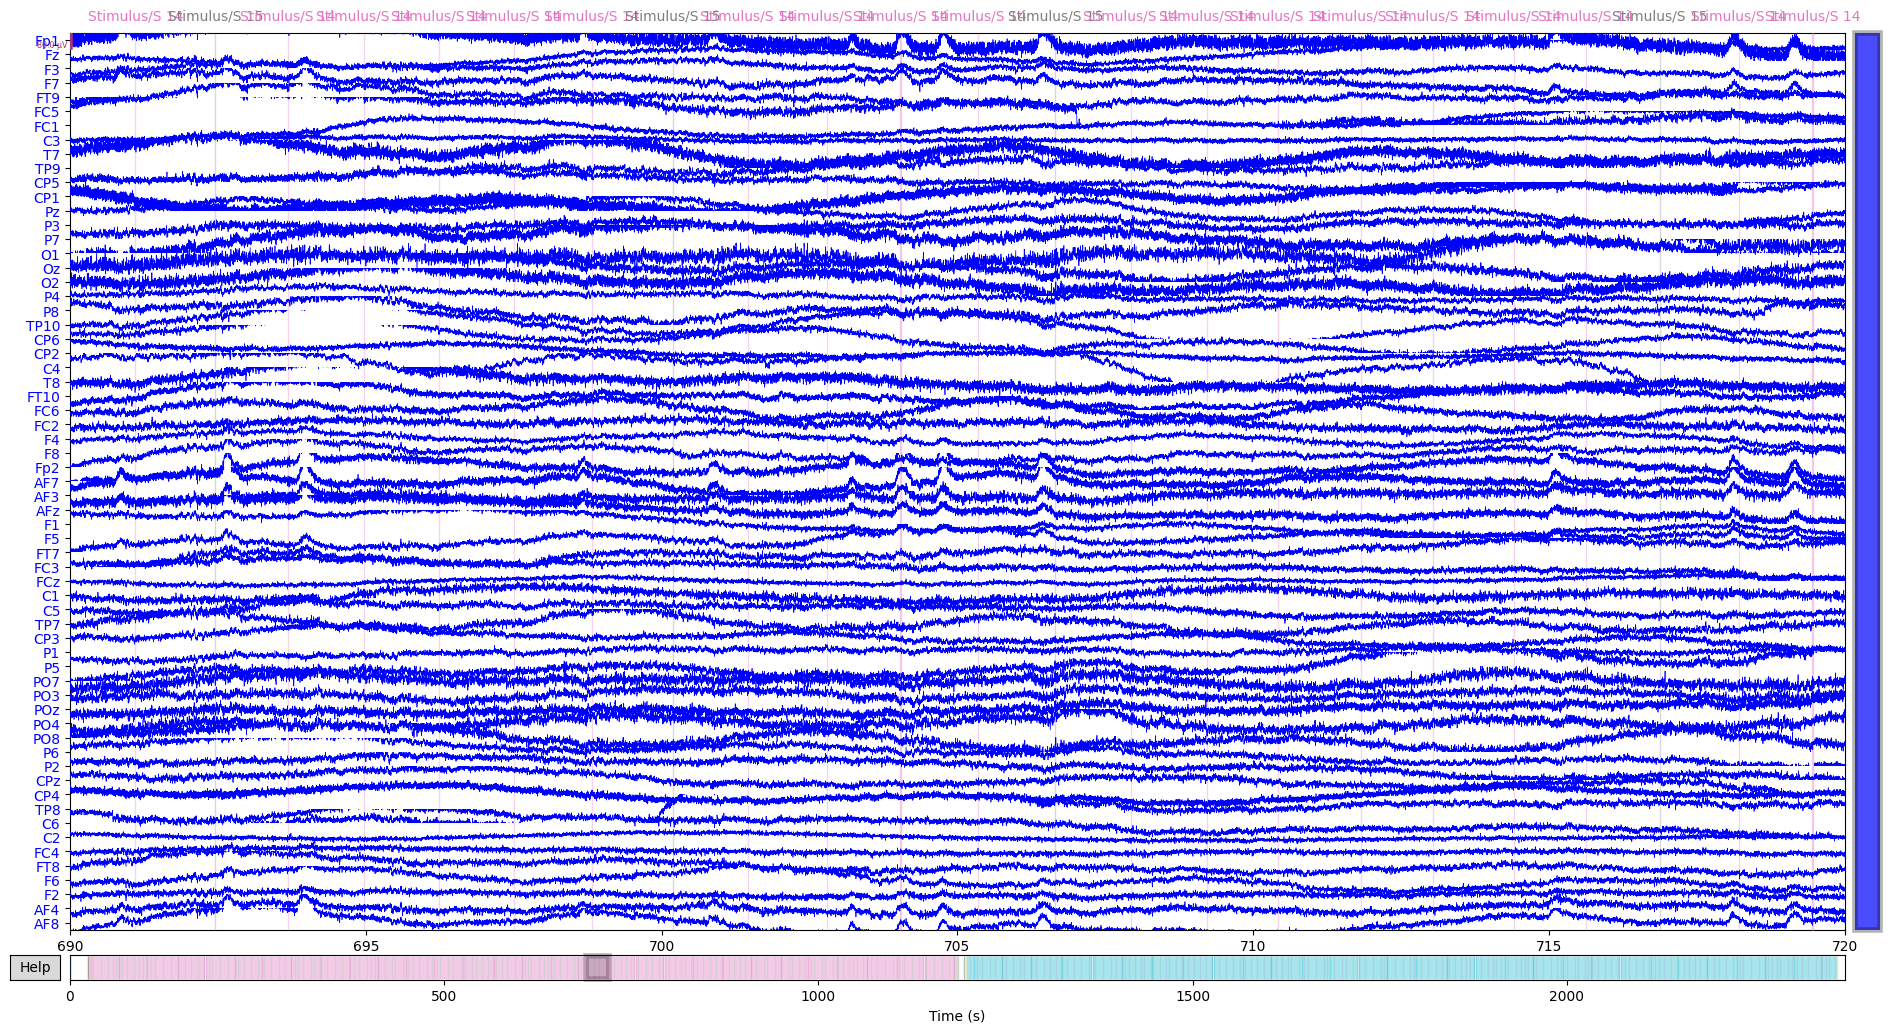

In [17]:
subject = "SD015"
path = os.path.join(data_folder,subject,data_type)
for eeg in os.listdir(path):
    if eeg[-5:] == ".vhdr":
            break
raw = mne.io.read_raw_brainvision(os.path.join(path,eeg), preload=True)
raw.set_montage("easycap-M1")
raw.plot(scalings=dict(eeg=40e-6),clipping='transparent',duration=30.0, start=690.0, n_channels=63,color = "Blue",event_color ='black',show_options=True )

In [18]:
# Now re-reference the data :-n average reference 
raw.set_eeg_reference('average')
# filter 
raw.filter(l_freq=0.1,h_freq=40)

eog_channels = ['Fp1', 'Fp2', 'F7', 'F8',"AF7",'AF8']  # Adjust these to match your channel names
 
events,event_dict = mne.events_from_annotations(raw)



eog_events = mne.preprocessing.find_eog_events(raw,ch_name=eog_channels)
onsets = eog_events[:, 0] / raw.info["sfreq"] - 0.25
durations = [0.5] * len(eog_events)
descriptions = ["bad blink"] * len(eog_events)
blink_annot = mne.Annotations(
    onsets, durations, descriptions, orig_time=raw.info["meas_date"]
)
raw.set_annotations(blink_annot)

raw.plot(events =events , scalings=dict(eeg=40e-6),clipping='transparent',duration=30.0, start=690.0, n_channels=63,color = "Blue" )
# Create Epochs
epochs = mne.Epochs(raw, events, event_id=[14,15] ,tmin=-0.300, tmax=0.700,
                    baseline=(None, 0), reject_by_annotation=True,
                    preload=True)
# Create Epochs
epochs = mne.Epochs(raw, events, event_id=[14,15] ,tmin=-0.300, tmax=0.700,
                    baseline=(None, 0), reject_by_annotation=True,
                    preload=True)

# Define your MMN channels
mmn_channels = ['F3', 'Fz', 'F4',]  # Example MMN channels, adjust as needed

# Remove epochs with bad MMN channels
cleaned_epochs = remove_epochs_with_bad_mmn_channels(epochs, mmn_channels)

print(f"Original number of epochs: {len(epochs)}")
print(f"Number of epochs after removal: {len(cleaned_epochs)}")
B1_devi_eps = cleaned_epochs['15'].average()
B1_sta_eps = cleaned_epochs["14"].average()
B1_MMN_erp = mne.combine_evoked([ B1_devi_eps,B1_sta_eps], weights=[1,-1])


evokeds = dict(B1_MMN_erp =B1_MMN_erp, B1_devi_eps= B1_devi_eps,B1_sta_eps=B1_sta_eps)  
#picks = [n for n in range(1, 5)]
picks= [ 'Fz']
mne.viz.plot_compare_evokeds(evokeds, picks=picks,title  = "SD015 on avaerage 'F3', 'Fz', 'F4'", combine="mean")

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 33001 samples (33.001 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    2.1s


Used Annotations descriptions: ['Comment/Active Shielding: On', 'New Segment/', 'Stimulus/S 11', 'Stimulus/S 12', 'Stimulus/S 13', 'Stimulus/S 14', 'Stimulus/S 15', 'Stimulus/S 21', 'Stimulus/S 24', 'Stimulus/S 25']
Using EOG channels: Fp1, Fp2, F7, F8, AF7, AF8
EOG channel index for this subject is: [ 0 30  3 29 31 62]
Filtering the data to remove DC offset to help distinguish blinks from saccades
Selecting channel Fp1 for blink detection
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 10000 samples (10.000 s)

Now detecting blinks and generating corresponding events
Found 230 sig

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_27952\2251223171.py:19: RuntimeWarning: Limited 2 annotation(s) that were expanding outside the data range.
  raw.set_annotations(blink_annot)


Not setting metadata
900 matching events found
Setting baseline interval to [-0.3, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 900 events and 1001 original time points ...
129 bad epochs dropped
Not setting metadata
900 matching events found
Setting baseline interval to [-0.3, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 900 events and 1001 original time points ...
129 bad epochs dropped


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_27952\88319035.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


Original number of epochs: 771
Number of epochs after removal: 771
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_27952\2251223171.py:47: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds, picks=picks,title  = "SD015 on avaerage 'F3', 'Fz', 'F4'", combine="mean")


[<Figure size 800x600 with 2 Axes>]

Channels marked as bad:
none
Channels marked as bad:
none
Channels marked as bad:
none
Channels marked as bad:
none
Channels marked as bad:
none
Channels marked as bad:
none
Channels marked as bad:
none
Channels marked as bad:
none
Channels marked as bad:
none
Channels marked as bad:
none
